Датасет - https://www.kaggle.com/datasets/shree1992/housedata

In [1]:
pip install XGBoost

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib as plt
import numpy as np
import seaborn as sns
import sklearn

In [48]:
data = pd.read_csv('/kaggle/input/housedata/data.csv')

In [5]:
data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [6]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [49]:
data = data[data['price'] > 1000]

In [50]:
data['street'] = data['city'] + ' ' + data['street']

In [51]:
data.drop(columns = 'country', inplace = True)

In [52]:
data.drop(columns = 'city', inplace = True)
data.drop(columns = 'statezip', inplace = True)

In [56]:
data.drop(columns = 'date', inplace = True)

In [53]:
X = data.drop(columns = 'price')

In [54]:
y = data['price']

In [55]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, shuffle=True, test_size = 0.2)

In [15]:
num_features = X_train.select_dtypes(include = ['float', 'int']).columns

<Axes: >

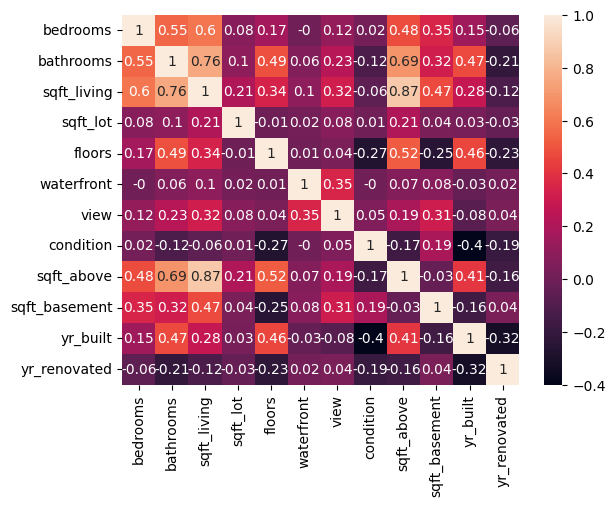

In [16]:
sns.heatmap(X_train[num_features].corr().round(2), annot=True)

In [17]:
import torch
from transformers import pipeline

In [18]:
transformate = pipeline(
    task="feature-extraction",
    model="google-bert/bert-base-uncased",
    dtype=torch.float16,
    device = 0
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [19]:
X_train['street'].shape

(3640,)

In [20]:
address_vectors = []

In [21]:
for sentence in X_train['street']:
    result = transformate(sentence)
    token_embeddings = np.array(result[0])
    address_vector = token_embeddings.mean(axis=0)
    address_vectors.append(address_vector)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [22]:
len(address_vectors)

3640

In [23]:
addres_matrix = np.stack(address_vectors)

In [24]:
addres_matrix.shape

(3640, 768)

In [25]:
PCA = sklearn.decomposition.PCA(n_components=50)

In [26]:
Decomposed = PCA.fit_transform(addres_matrix)

In [27]:
Decomposed.shape

(3640, 50)

In [28]:
PCA.get_feature_names_out()

array(['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7',
       'pca8', 'pca9', 'pca10', 'pca11', 'pca12', 'pca13', 'pca14',
       'pca15', 'pca16', 'pca17', 'pca18', 'pca19', 'pca20', 'pca21',
       'pca22', 'pca23', 'pca24', 'pca25', 'pca26', 'pca27', 'pca28',
       'pca29', 'pca30', 'pca31', 'pca32', 'pca33', 'pca34', 'pca35',
       'pca36', 'pca37', 'pca38', 'pca39', 'pca40', 'pca41', 'pca42',
       'pca43', 'pca44', 'pca45', 'pca46', 'pca47', 'pca48', 'pca49'],
      dtype=object)

In [29]:
PCAed = pd.DataFrame(Decomposed,columns = PCA.get_feature_names_out())

In [30]:
PCAed

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,...,pca40,pca41,pca42,pca43,pca44,pca45,pca46,pca47,pca48,pca49
0,-2.744010,-1.442962,-0.757173,0.159711,0.475501,0.708112,1.560389,-0.956428,-0.475656,-0.779754,...,-0.032372,-0.200429,0.441391,0.163933,0.673236,0.058565,0.048967,-0.195561,0.534178,0.080084
1,-1.325694,-0.575703,-1.371112,-0.604861,0.003847,-0.831592,-1.907178,0.068713,-0.368638,-0.588309,...,-0.242096,-0.023240,-0.332778,-0.236817,-0.039559,0.863226,-0.302452,-0.231658,-0.069453,-0.187918
2,-0.672139,-0.910257,1.278941,-0.352683,-0.574380,-0.516521,1.279609,0.326261,0.719994,0.864374,...,0.350766,-0.508912,-0.511850,0.277156,-0.100542,-0.501431,-0.180815,0.443930,0.410055,0.004338
3,0.252043,0.548313,-0.227092,0.016108,0.282048,-0.849951,-0.584608,-1.304400,-0.386379,-0.550705,...,0.581509,0.523722,-0.014066,0.230844,-0.008955,-0.292228,-0.046478,-0.257797,0.261656,-0.261389
4,0.585852,1.179135,-1.148004,-0.783915,-0.677301,-0.277524,0.160247,-0.486021,-0.111375,-0.140815,...,0.119837,0.040772,-0.248307,0.002270,0.664434,-0.023515,0.158535,-0.056243,-0.023471,-0.100085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3635,-0.267254,1.628247,2.171789,-0.648660,-0.133639,-0.009856,0.306499,-1.347256,0.179353,-0.516549,...,-0.018190,-0.180098,-0.192249,-0.223187,-0.756719,-0.485022,-0.128498,0.082856,0.195493,0.244106
3636,1.644824,-1.095250,0.370825,0.832217,0.285332,0.532782,-0.175453,0.055504,0.427327,-0.155204,...,-0.199381,0.510322,0.288764,0.115335,0.416451,0.317812,0.080183,0.179089,-0.186297,0.170392
3637,-0.166548,1.770250,0.388727,0.155189,-1.697792,1.036729,-0.720268,0.881093,-0.070898,0.972553,...,-0.182766,-0.019704,0.213792,0.259823,-0.328897,-0.526355,0.171559,0.254459,0.133175,-0.121907
3638,1.401542,-0.180926,0.568724,1.359830,-0.356743,-1.903452,0.024717,-1.136607,-0.444652,1.488746,...,0.030705,-0.122257,0.058924,0.110648,-0.281199,-0.160280,0.141770,0.322487,-0.003400,0.183234


In [31]:
X_train.drop(columns = 'street', inplace = True)

In [32]:
X_train = pd.concat([X_train.reset_index(), PCAed.reset_index()], axis = 1)

In [33]:
X_train.drop(columns = ['index'], inplace = True)

In [34]:
import xgboost as xgb
import optuna
from sklearn.model_selection import cross_val_score

In [35]:
print(X_train.columns.is_unique) 
if not X_train.columns.is_unique:
    X_train = X_train.loc[:, ~X_train.columns.duplicated()]

True


In [36]:
X_train.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'pca0', 'pca1', 'pca2', 'pca3', 'pca4',
       'pca5', 'pca6', 'pca7', 'pca8', 'pca9', 'pca10', 'pca11', 'pca12',
       'pca13', 'pca14', 'pca15', 'pca16', 'pca17', 'pca18', 'pca19', 'pca20',
       'pca21', 'pca22', 'pca23', 'pca24', 'pca25', 'pca26', 'pca27', 'pca28',
       'pca29', 'pca30', 'pca31', 'pca32', 'pca33', 'pca34', 'pca35', 'pca36',
       'pca37', 'pca38', 'pca39', 'pca40', 'pca41', 'pca42', 'pca43', 'pca44',
       'pca45', 'pca46', 'pca47', 'pca48', 'pca49'],
      dtype='object')

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [38]:
def objective(trial): 
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
    }

    model = xgb.XGBRegressor(**param, 
                              tree_method = 'hist', 
                              device =  'cuda')

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', model)
        
    ])

    score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring = 'neg_root_mean_squared_log_error').mean()

    return score

In [39]:
study = optuna.create_study(study_name="example_xgboost_study", direction='maximize') 
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=-1)   

best_params = study.best_params
print(best_params)

[I 2026-02-23 21:41:33,494] A new study created in memory with name: example_xgboost_study


  0%|          | 0/100 [00:00<?, ?it/s]

[21:41:35] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scorin

[W 2026-02-23 21:41:43,435] Trial 3 failed with parameters: {'max_depth': 5, 'learning_rate': 0.08256250749003631, 'n_estimators': 541, 'subsample': 0.6417973688589492, 'colsample_bytree': 0.9081312481732787, 'min_child_weight': 6, 'gamma': 3.895983789025835} because of the following error: The value nan is not acceptable.
[W 2026-02-23 21:41:43,437] Trial 3 failed with value np.float64(nan).
[I 2026-02-23 21:41:43,715] Trial 0 finished with value: -0.350792403112371 and parameters: {'max_depth': 6, 'learning_rate': 0.08341447940939924, 'n_estimators': 461, 'subsample': 0.9504312444668273, 'colsample_bytree': 0.5734561572542238, 'min_child_weight': 2, 'gamma': 3.848564269004708}. Best is trial 0 with value: -0.350792403112371.
[W 2026-02-23 21:41:44,317] Trial 1 failed with parameters: {'max_depth': 6, 'learning_rate': 0.06921426140059905, 'n_estimators': 529, 'subsample': 0.8588501630635088, 'colsample_bytree': 0.5995653401682992, 'min_child_weight': 10, 'gamma': 0.9049354244623309} b

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py", line 822, in root_mean_squared_log_error
    raise ValueError(
ValueError: Root Mean Squared Logarithmic Erro

...

[W 2026-02-23 21:47:40,303] Trial 95 failed with parameters: {'max_depth': 5, 'learning_rate': 0.05791406799746379, 'n_estimators': 960, 'subsample': 0.5574521211580519, 'colsample_bytree': 0.5360665136183175, 'min_child_weight': 6, 'gamma': 0.9347572230296739} because of the following error: The value nan is not acceptable.
[W 2026-02-23 21:47:40,305] Trial 95 failed with value np.float64(nan).


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py", line 822, in root_mean_squared_log_error
    raise ValueError(
ValueError: Root Mean Squared Logarithmic Erro

[W 2026-02-23 21:47:50,073] Trial 96 failed with parameters: {'max_depth': 5, 'learning_rate': 0.057716134499593605, 'n_estimators': 910, 'subsample': 0.5808947169388848, 'colsample_bytree': 0.5054164275164128, 'min_child_weight': 6, 'gamma': 0.6394748580655996} because of the following error: The value nan is not acceptable.
[W 2026-02-23 21:47:50,074] Trial 96 failed with value np.float64(nan).
[W 2026-02-23 21:47:51,257] Trial 97 failed with parameters: {'max_depth': 5, 'learning_rate': 0.05864038757412331, 'n_estimators': 977, 'subsample': 0.5686487463789284, 'colsample_bytree': 0.5072860557503477, 'min_child_weight': 6, 'gamma': 0.6625865285447405} because of the following error: The value nan is not acceptable.
[W 2026-02-23 21:47:51,259] Trial 97 failed with value np.float64(nan).
[W 2026-02-23 21:47:51,729] Trial 98 failed with parameters: {'max_depth': 5, 'learning_rate': 0.05755950395780434, 'n_estimators': 991, 'subsample': 0.5388234251216149, 'colsample_bytree': 0.517051529

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py", line 822, in root_mean_squared_log_error
    raise ValueError(
ValueError: Root Mean Squared Logarithmic Erro

[W 2026-02-23 21:47:53,018] Trial 99 failed with parameters: {'max_depth': 5, 'learning_rate': 0.053535867700970054, 'n_estimators': 917, 'subsample': 0.5404401232281264, 'colsample_bytree': 0.5027145299396967, 'min_child_weight': 6, 'gamma': 0.516808428671649} because of the following error: The value nan is not acceptable.
[W 2026-02-23 21:47:53,019] Trial 99 failed with value np.float64(nan).
{'max_depth': 5, 'learning_rate': 0.03969048665141677, 'n_estimators': 859, 'subsample': 0.9628902230802654, 'colsample_bytree': 0.6682664422534017, 'min_child_weight': 1, 'gamma': 2.10266057545481}


In [40]:
from sklearn.metrics import r2_score, mean_absolute_error

best_model = xgb.XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_train)

In [41]:
r2 = r2_score(y_train, y_pred)
print(f"R^2: {r2}")

MAE = mean_absolute_error(y_train, y_pred)
print(f"MAE: {MAE}")

R^2: 0.996189348934251
MAE: 25302.64099155794


In [43]:
X_test

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street
415,4.0,2.00,2190,14439,1.0,0,0,4,1180,1010,1977,0,3331 S 368th Pl
3598,3.0,2.75,2600,64626,1.5,0,0,3,2600,0,2009,0,69506 NE Money Creek Rd
564,5.0,2.25,3120,16672,2.0,0,0,4,3120,0,1969,0,9045 NE 40th Pl
651,3.0,2.50,1840,5011,2.0,0,0,3,1840,0,2012,1912,21560 SE 275th Ct
3834,5.0,2.50,2450,6994,2.0,0,0,3,2450,0,2002,0,11207 SE 272nd Pl
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094,4.0,2.50,2000,37045,2.0,0,0,3,2000,0,1989,0,29204 202nd Ave SE
497,3.0,2.50,1940,4927,2.0,0,0,3,1940,0,2004,2003,17217 Woodside Dr SE
3361,5.0,2.50,2700,16570,1.0,0,0,4,1750,950,1967,0,428 129th Pl NE
3043,2.0,1.00,970,4560,1.0,0,0,4,970,0,1907,0,4017 Corliss Ave N


In [58]:
address_vectors_test = []
for sentence in X_test['street']:
    result = transformate(sentence)
    token_embeddings = np.array(result[0])
    address_vector = token_embeddings.mean(axis=0)
    address_vectors_test.append(address_vector)

address_matrix_test = np.stack(address_vectors_test)

pca_features_test = PCA.transform(address_matrix_test)
pca_df_test = pd.DataFrame(pca_features_test, columns=[f'pca{i}' for i in range(pca_features_test.shape[1])])

X_test = X_test.drop(columns=['street'])

X_test = X_test.reset_index(drop=True)
pca_df_test = pca_df_test.reset_index(drop=True)

X_test = pd.concat([X_test, pca_df_test], axis=1)

if not X_test.columns.is_unique:
    X_test = X_test.loc[:, ~X_test.columns.duplicated()]

In [59]:
y_pred = best_model.predict(X_test)

In [62]:
r2 = r2_score(y_test, y_pred)
print(f"R^2: {r2}")

MAE = mean_absolute_error(y_test, y_pred)
print(f"MAE: {MAE}")

R^2: 0.9192118545777432
MAE: 45900.40126579857
